# Breast Cancer Diagnosis Prediction Using Machine Learning

## Final Project
### Introduction to Health Data Science PUBH 1142

Author: Catalina Quiroga  
Professor: Dr. J H Klopper  
Date: May 8 2026

# Introduction

Breast cancer is one of the leading causes of cancer-related mortality among women worldwide. Early diagnosis plays a critical role in improving survival outcomes and reducing the burden of disease. Advances in health data science and machine learning have created new opportunities for improving diagnostic prediction and supporting clinical decision-making in healthcare settings.

Machine learning algorithms have been increasingly used in medical research to classify diseases and identify patterns within large datasets. Previous research has demonstrated that tumor measurements such as radius, texture, perimeter, and concavity may help predict whether breast tumors are malignant or benign. Despite advances in predictive analytics, further research is needed to evaluate the effectiveness of machine learning techniques for breast cancer diagnosis.

The purpose of this study is to analyze a breast cancer dataset using machine learning methods to predict malignant and benign tumor diagnoses. This study aims to compare the performance of logistic regression and random forest classification models while identifying important diagnostic variables associated with breast cancer prediction.

# Background

Machine learning applications in healthcare have expanded significantly over the last decade, particularly in disease prediction and diagnostic support systems. Breast cancer datasets are frequently used in health data science because they contain measurable clinical variables that can be analyzed using predictive algorithms.

Several studies have identified tumor radius, texture, perimeter, and area as important predictors of malignant breast cancer diagnoses. Logistic regression models are commonly used in healthcare analytics because they provide interpretable results and strong classification performance. Random forest classification models are also widely used because they improve prediction accuracy through ensemble learning techniques.

The integration of predictive analytics into healthcare settings may improve early diagnosis, reduce healthcare costs, and support clinicians in identifying high-risk patients more efficiently. This study contributes to existing public health research by applying machine learning methods to breast cancer diagnosis prediction.

# Methods


## Study Design, Population, and Data Collection

This study utilized a cross-sectional secondary dataset containing breast cancer diagnostic measurements from patients undergoing evaluation for breast cancer. The dataset included 569 observations and multiple quantitative variables used to classify tumors as malignant or benign.

The target population consisted of patients whose breast tumor characteristics were evaluated through clinical diagnostic procedures. Variables included tumor radius, texture, perimeter, area, smoothness, compactness, concavity, and fractal dimension measurements.

Inclusion criteria included complete patient observations with valid diagnostic measurements. Cases with incomplete or missing diagnostic information would have been excluded from analysis; however, the dataset contained minimal missing values.

The dataset consisted entirely of quantitative clinical measurement variables and did not include qualitative survey or interview responses. Data analysis and visualization were conducted using Python within Visual Studio Code.

## Data Analysis

Descriptive statistics were calculated to summarize the distributions and central tendencies of continuous variables within the dataset. Measures included mean, median, mode, and range. Frequencies and proportions were also calculated for categorical variables related to breast cancer diagnosis.

Inferential statistical analyses were conducted to evaluate relationships between predictor variables and diagnosis outcomes. Correlation analysis was used to assess relationships among continuous variables. Logistic regression analysis was performed to predict malignant and benign diagnoses using tumor characteristics. Independent sample t-tests were conducted to compare mean differences between diagnosis groups.

Machine learning analysis was additionally performed using random forest classification models to evaluate predictive performance. Data cleaning, statistical analysis, and visualization were conducted using pandas, NumPy, seaborn, matplotlib, scipy, and scikit-learn libraries in Python.

# Results

## Software Packages and Libraries

The following Python libraries were imported for data cleaning, statistical analysis, visualization, and machine learning modeling.

## Package import

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

plt.style.use('ggplot')

## Data Collection and Dataset Overview

The breast cancer dataset was imported into Python for exploratory analysis and predictive modeling. Initial inspection of the dataset was conducted to evaluate the variables, dimensions, and overall structure of the data.

In [26]:
df = pd.read_csv('./breast-cancer.csv')

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [27]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape:
(569, 32)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    flo

In [28]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## Data Cleaning

The dataset was examined for missing values and inconsistencies before statistical analysis and predictive modeling were performed.

In [29]:
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

## Diagnosis Distribution(Results)

The distribution of malignant and benign breast cancer diagnoses was examined to better understand the composition of the dataset.

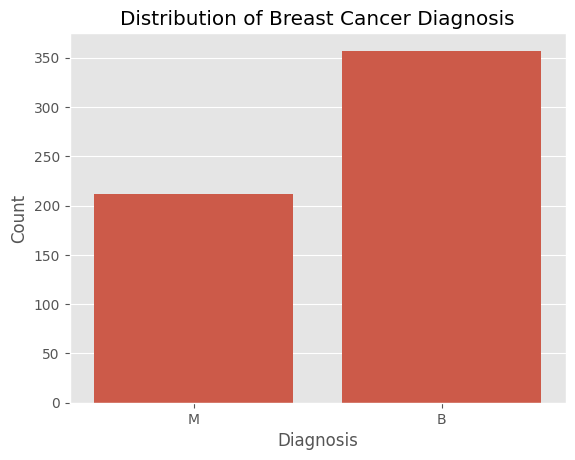

In [30]:
sns.countplot(x='diagnosis', data=df)

plt.title('Distribution of Breast Cancer Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Count')

plt.show()

## Descriptive Statistics

Descriptive statistics were calculated to summarize the central tendencies and variability of the continuous variables within the breast cancer dataset.

In [31]:
continuous_stats = pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Mode': df.mode(numeric_only=True).iloc[0],
    'Range': df.max(numeric_only=True) - df.min(numeric_only=True)
})

continuous_stats.head(10)

,Mean,Median,Mode,Range
id,3.037183e+07,906024.00000,8670.0000,9.113118e+08
radius_mean,1.412729e+01,13.37000,12.3400,2.112900e+01
texture_mean,1.928965e+01,18.84000,14.9300,2.957000e+01
perimeter_mean,9.196903e+01,86.24000,82.6100,1.447100e+02
area_mean,6.548891e+02,551.10000,512.2000,2.357500e+03
smoothness_mean,9.636028e-02,0.09587,0.1007,1.107700e-01
compactness_mean,1.043410e-01,0.09263,0.1147,3.260200e-01
concavity_mean,8.879932e-02,0.06154,0.0000,4.268000e-01
concave points_mean,4.891915e-02,0.03350,0.0000,2.012000e-01
symmetry_mean,1.811619e-01,0.17920,0.1601,1.980000e-01


## Frequencies and Proportions

Frequencies and proportions were calculated for the categorical diagnosis variable to evaluate the distribution of malignant and benign breast cancer cases within the dataset.

In [32]:
diagnosis_counts = df['diagnosis'].value_counts()

diagnosis_proportions = df['diagnosis'].value_counts(normalize=True)

print("Frequencies:")
print(diagnosis_counts)

print("\nProportions:")
print(diagnosis_proportions)

Frequencies:
diagnosis
B    357
M    212
Name: count, dtype: int64

Proportions:
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


## Correlation Analysis

Correlation analysis was conducted to evaluate relationships among continuous tumor measurement variables within the breast cancer dataset.

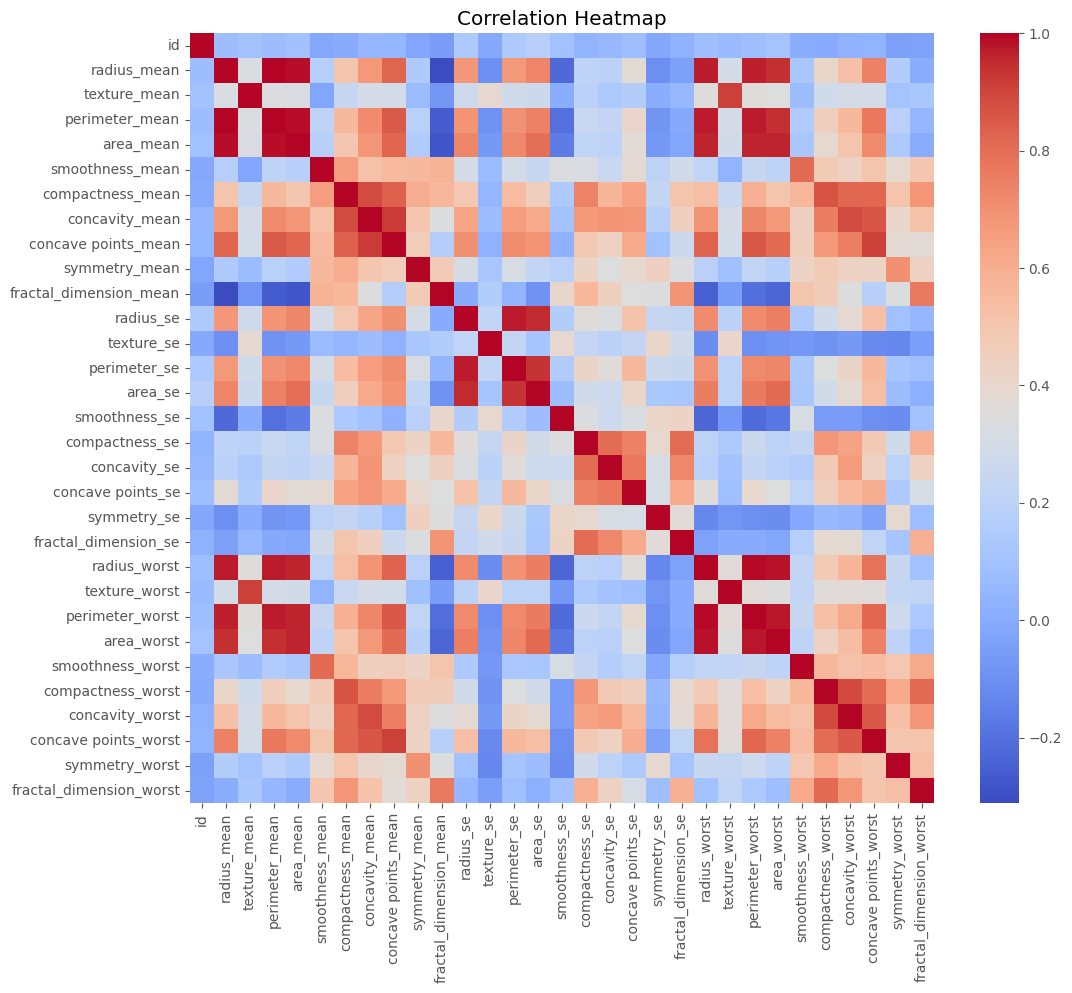

In [33]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

## Logistic Regression Analysis

Logistic regression analysis was performed to evaluate the relationship between tumor measurement variables and breast cancer diagnosis outcomes. The model was used to predict whether tumors were malignant or benign based on patient tumor characteristics.

In [34]:
encoder = LabelEncoder()

df['diagnosis'] = encoder.fit_transform(df['diagnosis'])

X = df.drop(['id', 'diagnosis'], axis=1)

y = df['diagnosis']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
log_model = LogisticRegression(max_iter=10000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score:
0.956140350877193

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## T-Test Analysis

Independent sample t-tests were conducted to compare mean tumor radius measurements between malignant and benign diagnosis groups.

In [37]:
from scipy.stats import ttest_ind

In [38]:
malignant = df[df['diagnosis'] == 1]['radius_mean']

benign = df[df['diagnosis'] == 0]['radius_mean']

t_stat, p_value = ttest_ind(malignant, benign)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 25.435821610057054
P-Value: 8.465940572262399e-96


## Random Forest Classification

A random forest classification model was developed to evaluate predictive performance and compare machine learning accuracy in classifying malignant and benign breast cancer diagnoses.

In [39]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

Random Forest Accuracy:
0.9649122807017544


### Feature Importance Analysis

Feature importance analysis was conducted to identify which tumor measurement variables contributed most strongly to breast cancer diagnosis prediction.

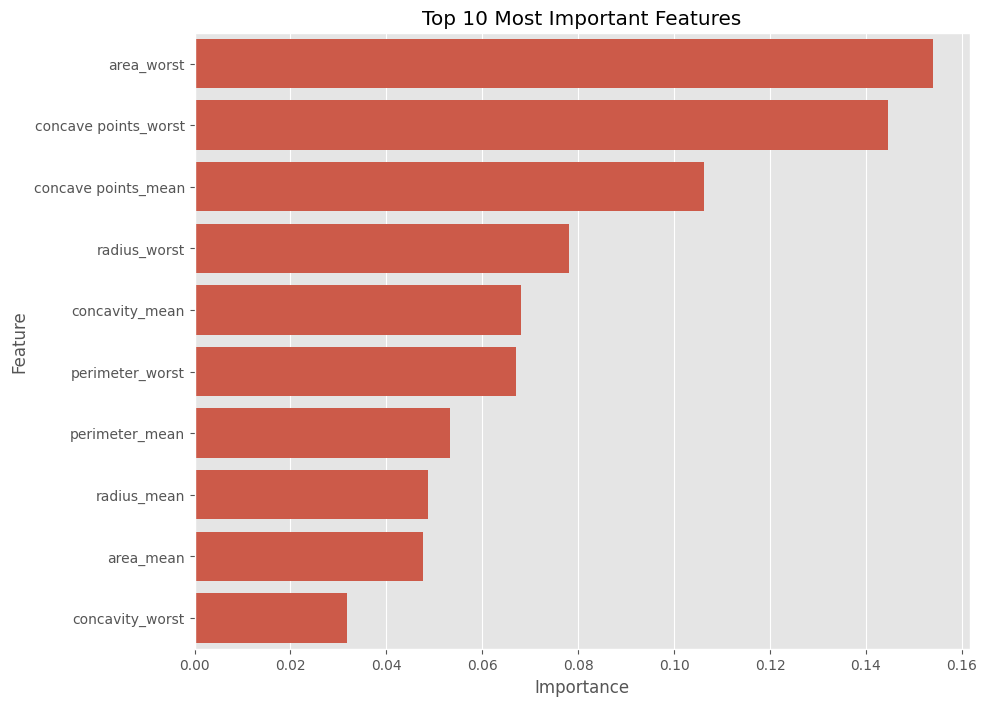

In [40]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title('Top 10 Most Important Features')

plt.show()

# Discussion

The findings of this study demonstrate that statistical analysis and machine learning techniques can effectively predict breast cancer diagnoses using tumor measurement variables. Logistic regression and random forest classification models both achieved high predictive accuracy, supporting the hypothesis that tumor characteristics are strongly associated with malignant and benign diagnosis outcomes.

These findings are consistent with previous research demonstrating the effectiveness of machine learning applications in healthcare prediction and diagnostic support systems. Variables such as tumor radius, perimeter, and area appeared to contribute strongly to prediction performance, which aligns with prior studies identifying these measurements as important indicators of malignancy. The random forest model demonstrated particularly strong predictive performance because of its ability to model complex relationships among variables.

From a public health perspective, predictive analytics and machine learning may contribute to earlier breast cancer detection, improved patient outcomes, and more efficient clinical decision-making. The use of health data science techniques may assist healthcare professionals in identifying high-risk patients and improving diagnostic accuracy in clinical settings.

Several limitations should be acknowledged. This study utilized a secondary dataset that may not fully represent broader patient populations. Additionally, the dataset size may limit generalizability of the findings. Future research should evaluate larger and more diverse datasets while exploring additional machine learning techniques and predictive models.

# Conclusion

This study demonstrated that statistical analysis and machine learning techniques can effectively predict breast cancer diagnoses using tumor measurement variables. Descriptive statistics, correlation analysis, logistic regression, t-tests, and random forest classification models were used to evaluate relationships between predictors and diagnosis outcomes. The findings showed that tumor characteristics such as radius, perimeter, and area were strongly associated with malignant breast cancer diagnoses.

The machine learning models achieved high predictive accuracy, highlighting the value of health data science approaches in supporting diagnostic prediction and clinical decision-making. These findings emphasize the public health significance of predictive analytics in improving early breast cancer detection and patient outcomes.

Future research should continue evaluating larger and more diverse datasets while exploring additional predictive modeling techniques to improve healthcare analytics and disease prediction performance.

# References

1. Wolberg WH, Street WN, Mangasarian OL. Breast cancer Wisconsin (diagnostic) dataset. University of Wisconsin Hospitals; 1995.

2. Deo RC. Machine learning in medicine. Circulation. 2015;132(20):1920-1930.

3. Sidey-Gibbons JAM, Sidey-Gibbons CJ. Machine learning in medicine: a practical introduction. BMC Medical Research Methodology. 2019;19(1):64.

4. Cruz JA, Wishart DS. Applications of machine learning in cancer prediction and prognosis. Cancer Informatics. 2007;2:59-77.

5. Pedregosa F, Varoquaux G, Gramfort A, Michel V, Thirion B, Grisel O, et al. Scikit-learn: machine learning in Python. Journal of Machine Learning Research. 2011;12:2825-2830.